In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

C:\Users\sheha\AppData\Local\Temp\ipykernel_26560\1161821594.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


Test Evaluation Metrics -> RMSE: 2.009, MAE: 1.214, R2: 0.803


FileNotFoundError: [Errno 2] No such file or directory: '../notebooks/residual_plot.png'

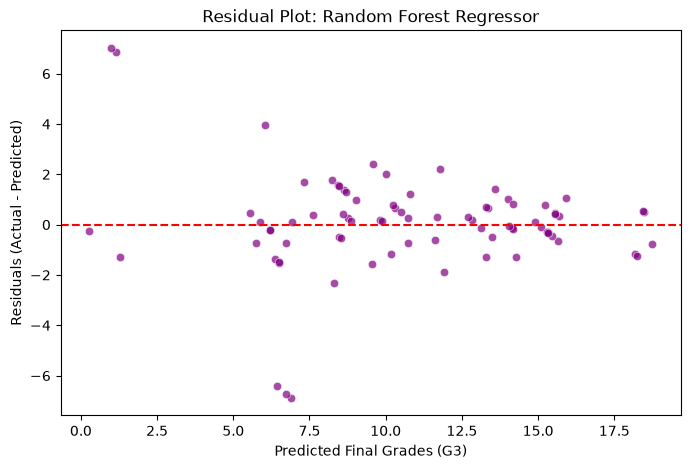

In [ ]:
def evaluate_best_model():
    # Load dataset
    df = pd.read_csv('../data/student-mat.csv', sep=';')
    X = df.drop(columns=['G3'])
    y = df['G3']
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Preprocessor
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ],
        remainder='passthrough'
    )
    
    # Using Random Forest as the representative high-performing model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Test Evaluation Metrics -> RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    
    # Residual Plot Generation
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.7)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title('Residual Plot: Random Forest Regressor')
    plt.xlabel('Predicted Final Grades (G3)')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.savefig('residual_plot.png')
    plt.close()
    print("Residual plot saved successfully.")

if __name__ == '__main__':
    evaluate_best_model()